In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from quantization import *
from utils import *
from profiler import *

### Config

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_WORKERS = 2
QAT_EPOCHS = 3  # As per assignment, a few epochs for QAT
QAT_LR = 1e-5
BASELINE_MODEL_PATH = 'vgg11_cifar100_fp32.pth'
print(f"Using device: {DEVICE}")

Using device: cuda


### Dataloader

In [3]:
print("Setting up CIFAR-100 dataset...")
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Create a calibration dataloader from a subset of the training data
calib_indices = np.random.choice(len(trainset), 528, replace=False)
calib_subset = Subset(trainset, calib_indices)
calib_loader = DataLoader(calib_subset, batch_size=BATCH_SIZE, shuffle=False)

Setting up CIFAR-100 dataset...
Files already downloaded and verified
Files already downloaded and verified


### Baseline

In [5]:
vgg11_fp32 = torchvision.models.vgg11_bn(num_classes=100)

if os.path.exists(BASELINE_MODEL_PATH):
    print(f"Loading pre-trained baseline model from {BASELINE_MODEL_PATH}")
    vgg11_fp32.load_state_dict(torch.load(BASELINE_MODEL_PATH))
else:
    print("No pre-trained model found. Training a new baseline model...")
    # NOTE: Training from scratch takes time. For the assignment, 20 epochs is a good start.
    vgg11_fp32 = train_baseline(vgg11_fp32, train_loader, test_loader, epochs=20)
    torch.save(vgg11_fp32.state_dict(), BASELINE_MODEL_PATH)

vgg11_fp32.to(DEVICE)
print("\nBaseline FP32 model is ready.")

No pre-trained model found. Training a new baseline model...
Epoch 1/20, Loss: 4.155, Val Acc: 10.51%
Epoch 2/20, Loss: 3.800, Val Acc: 13.73%
Epoch 3/20, Loss: 3.531, Val Acc: 19.90%
Epoch 4/20, Loss: 3.254, Val Acc: 23.22%
Epoch 5/20, Loss: 3.023, Val Acc: 29.50%
Epoch 6/20, Loss: 2.822, Val Acc: 32.53%
Epoch 7/20, Loss: 2.633, Val Acc: 35.56%
Epoch 8/20, Loss: 2.487, Val Acc: 38.50%
Epoch 9/20, Loss: 2.337, Val Acc: 41.65%
Epoch 10/20, Loss: 2.203, Val Acc: 43.02%
Epoch 11/20, Loss: 2.087, Val Acc: 44.76%
Epoch 12/20, Loss: 1.972, Val Acc: 46.60%
Epoch 13/20, Loss: 1.870, Val Acc: 49.47%
Epoch 14/20, Loss: 1.774, Val Acc: 50.24%
Epoch 15/20, Loss: 1.668, Val Acc: 52.52%
Epoch 16/20, Loss: 1.579, Val Acc: 53.63%
Epoch 17/20, Loss: 1.504, Val Acc: 54.62%
Epoch 18/20, Loss: 1.439, Val Acc: 55.54%
Epoch 19/20, Loss: 1.401, Val Acc: 55.77%
Epoch 20/20, Loss: 1.375, Val Acc: 55.95%

Baseline FP32 model is ready.


In [4]:
vgg11_fp32 = torchvision.models.vgg11_bn(num_classes=100)
fp32_model = vgg11_fp32 
fp32_model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=DEVICE))
fp32_model = fp32_model.to(DEVICE)  
fp32_model.eval() 
vgg11_fp32 = fp32_model
print("FP32 model loaded successfully!")

C:\Users\Laptop Gala\AppData\Local\Temp\ipykernel_16780\2076128674.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fp32_model.load_state_dict(torch.load(BASELINE_MODEL_P

FP32 model loaded successfully!


### FP32

In [5]:
results_data = []
# --- 1. Evaluate FP32 Baseline ---
print("--- Evaluating FP32 Baseline ---")
fp32_model = deepcopy(vgg11_fp32).to(DEVICE)
fp32_acc = evaluate(fp32_model, test_loader, DEVICE)
fp32_size = get_model_size(fp32_model)
results_data.append({'Method': 'Baseline', 'Precision': 'fp32', 'Bits': 32, 'Accuracy': fp32_acc, 'Size (MB)': fp32_size})
print(f"FP32 Baseline | Accuracy: {fp32_acc:.2f}%, Size: {fp32_size:.2f} MB")


--- Evaluating FP32 Baseline ---
FP32 Baseline | Accuracy: 55.95%, Size: 492.81 MB


### PTQ Experiments

In [6]:
print("\n--- Running PTQ & Profiling Experiments ---")
ptq_precisions = {
    'fp32': 32,
    'fp16': 16,
    'bf16': 16,
    'int8': 8,
    'int4': 4
}
results_data_ptq = []

for prec, bits in ptq_precisions.items():
    print(f"\n{'='*25} Processing: PTQ {prec.upper()} (Symmetric) {'='*25}")
    model_to_process = deepcopy(vgg11_fp32)

    if prec == 'fp32':
        quantized_model = model_to_process # No conversion needed
        model_size = get_model_size(quantized_model)
    elif prec == 'fp16':
        quantized_model = model_to_process.half()
        model_size = get_model_size(quantized_model)
    elif prec == 'bf16':
        quantized_model = model_to_process.bfloat16()
        model_size = get_model_size(quantized_model)
    else: # int8 and int4 (Symmetric by default)
        quantized_model = ptq_pipeline(model_to_process, calib_loader, DEVICE, bitwidth=bits, sym=True)
        model_size = get_model_size(quantized_model, bitwidth=bits)
        
    print("Evaluating accuracy...")
    acc = evaluate(quantized_model, test_loader, DEVICE)
    print(f"-> Accuracy: {acc:.2f}%, Size: {model_size:.2f} MB")

    model_name_str = f"PTQ_{prec.upper()}_Symm" if prec in ['int8', 'int4'] else f"PTQ_{prec.upper()}"
    inference_results = profile_model_performance(
        model=quantized_model, 
        model_name=model_name_str, 
        model_size_mb=model_size,
        dataloader=test_loader, 
        device=DEVICE
    )
    
    final_results = {
        'Method': 'PTQ',
        'Precision': f"{prec}_symm" if prec in ['int8', 'int4'] else prec,
        'Bits': bits,
        'Accuracy (%)': acc,
        'Size (MB)': model_size,
    }
    final_results.update(inference_results)
    results_data.append(final_results)

    if prec == 'int4':
        print(f"\n{'='*25} Processing: PTQ INT4 (Asymmetric) {'='*25}")
        model_to_process_asymm = deepcopy(vgg11_fp32)
        quantized_model_asymm = ptq_pipeline(model_to_process_asymm, calib_loader, DEVICE, bitwidth=bits, sym=False)
        model_size_asymm = get_model_size(quantized_model_asymm, bitwidth=bits)

        print("Evaluating accuracy...")
        acc_asymm = evaluate(quantized_model_asymm, test_loader, DEVICE)
        print(f"-> Accuracy: {acc_asymm:.2f}%, Size: {model_size_asymm:.2f} MB")

        inference_results_asymm = profile_model_performance(
            model=quantized_model_asymm, 
            model_name="PTQ_INT4_Asymm", 
            model_size_mb=model_size_asymm,
            dataloader=test_loader, 
            device=DEVICE
        )
        
        final_results_asymm = {
            'Method': 'PTQ',
            'Precision': 'int4_asymm',
            'Bits': bits,
            'Accuracy (%)': acc_asymm,
            'Size (MB)': model_size_asymm,
        }
        final_results_asymm.update(inference_results_asymm)
        results_data.append(final_results_asymm)
try:
    import pandas as pd
    df = pd.DataFrame(results_data)
    df.set_index('Model', inplace=True)
    print("\n\n" + "="*80)
    print("                              PTQ FINAL RESULTS SUMMARY")
    print("="*80)
    pd.options.display.float_format = '{:.2f}'.format
    print(df)
except ImportError:
    print("\n\n--- FINAL RESULTS ---")
    for res in results_data:
        print(res)


--- Running PTQ & Profiling Experiments ---

========================= Processing: PTQ FP32 (Symmetric) =========================
Evaluating accuracy...
-> Accuracy: 55.95%, Size: 492.81 MB

========================= Processing: PTQ FP16 (Symmetric) =========================
Evaluating accuracy...
-> Accuracy: 55.91%, Size: 246.40 MB

========================= Processing: PTQ BF16 (Symmetric) =========================
Evaluating accuracy...
-> Accuracy: 56.01%, Size: 246.40 MB

========================= Processing: PTQ INT8 (Symmetric) =========================
Calibrating model...
Applying quantization...
PTQ completed!
Evaluating accuracy...
-> Accuracy: 55.63%, Size: 123.22 MB

========================= Processing: PTQ INT4 (Symmetric) =========================
Calibrating model...
Applying quantization...
PTQ completed!
Evaluating accuracy...
-> Accuracy: 14.70%, Size: 61.63 MB

========================= Processing: PTQ INT4 (Asymmetric) =========================
Calibrating model

### QAT Experiments

In [7]:
results_data_qat = [] 
print("\n--- Running QAT Experiments ---")
qat_precisions = {
    'int8': 8,
    'int4': 4
}
QAT_EPOCHS = 5 

for prec, bits in qat_precisions.items():
    print(f"\n--- QAT for {prec} (Symmetric, {QAT_EPOCHS} epochs) ---")
    model_to_quantize_symm = deepcopy(vgg11_fp32)
    
    quantized_model_symm = qat_pipeline(model_to_quantize_symm, train_loader, test_loader, calib_loader, DEVICE, 
                                        bitwidth=bits, epochs=QAT_EPOCHS, sym=True)
    
    model_size_symm = get_model_size(quantized_model_symm, bitwidth=bits)
    acc_symm = evaluate(quantized_model_symm, test_loader, DEVICE)
    print(f"QAT {prec} (Symmetric) | Accuracy: {acc_symm:.2f}%, Size: {model_size_symm:.2f} MB")
    
    results_data_qat.append({
        'Method': 'QAT', 
        'Precision': f'{prec}_symm', 
        'Bits': bits, 
        'Accuracy (%)': acc_symm, 
        'Size (MB)': model_size_symm
    })

    if prec == 'int4':
        print(f"\n--- QAT for {prec} (Asymmetric, {QAT_EPOCHS} epochs) ---")
        model_to_quantize_asymm = deepcopy(vgg11_fp32)
        quantized_model_asymm = qat_pipeline(model_to_quantize_asymm, train_loader, test_loader, calib_loader, DEVICE, 
                                             bitwidth=bits, epochs=QAT_EPOCHS, sym=False)
        
        model_size_asymm = get_model_size(quantized_model_asymm, bitwidth=bits)
        acc_asymm = evaluate(quantized_model_asymm, test_loader, DEVICE)
        print(f"QAT {prec} (Asymmetric) | Accuracy: {acc_asymm:.2f}%, Size: {model_size_asymm:.2f} MB")
        
        results_data_qat.append({
            'Method': 'QAT', 
            'Precision': 'int4_asymm', 
            'Bits': bits, 
            'Accuracy (%)': acc_asymm, 
            'Size (MB)': model_size_asymm
        })
try:
    import pandas as pd
    df_qat = pd.DataFrame(results_data_qat)
    print("\n\n" + "="*80)
    print("                              QAT FINAL RESULTS SUMMARY")
    print("="*80)
    pd.options.display.float_format = '{:.2f}'.format
    print(df_qat)
except ImportError:
    print("\n\n--- FINAL QAT RESULTS ---")
    for res in results_data_qat:
        print(res)


--- Running QAT Experiments ---

--- QAT for int8 (Symmetric, 5 epochs) ---
Starting QAT with bitwidth=8, epochs=5, lr=1e-05
Configuring QAT for Symmetric, Per-Tensor weights.
Preparing model for QAT...
Training QAT model...
QAT Epoch 1/5 | Training Loss: 1.376 | Validation Accuracy: 55.59%
QAT Epoch 2/5 | Training Loss: 1.359 | Validation Accuracy: 55.59%
QAT Epoch 3/5 | Training Loss: 1.345 | Validation Accuracy: 55.70%
QAT Epoch 4/5 | Training Loss: 1.328 | Validation Accuracy: 55.90%
QAT Epoch 5/5 | Training Loss: 1.317 | Validation Accuracy: 55.68%

Converting trained QAT model to final quantized format...
Unwrapping QAT model...
Applying PTQ to the fine-tuned model...
Calibrating model...
Applying quantization...
PTQ completed!
QAT completed!
QAT int8 (Symmetric) | Accuracy: 55.57%, Size: 123.22 MB

--- QAT for int4 (Symmetric, 5 epochs) ---
Starting QAT with bitwidth=4, epochs=5, lr=1e-05
Configuring QAT for Symmetric, Per-Tensor weights.
Preparing model for QAT...
Training QAT

### Summary

In [8]:
df_results = pd.DataFrame(results_data)
print("\n--- Summary ptq Results ---")
print(df_results)

df_results = pd.DataFrame(results_data_qat)
print("\n--- Summary qat Results ---")
print(df_results)


--- Summary ptq Results ---
     Method   Precision  Bits  Accuracy Size (MB)  Accuracy (%)  \
0  Baseline        fp32    32     55.95    492.81           NaN   
1       PTQ        fp32    32       NaN    492.81         55.95   
2       PTQ        fp16    16       NaN    246.40         55.91   
3       PTQ        bf16    16       NaN    246.40         56.01   
4       PTQ   int8_symm     8       NaN    123.22         55.63   
5       PTQ   int4_symm     4       NaN     61.63         14.70   
6       PTQ  int4_asymm     4       NaN     61.76         18.69   

            Model Avg Latency (ms/batch) Throughput (img/sec)  
0             NaN                    NaN                  NaN  
1        PTQ_FP32                   5.67             22594.55  
2        PTQ_FP16                  11.03             11607.71  
3        PTQ_BF16                  10.75             11907.15  
4   PTQ_INT8_Symm                  23.25              5505.77  
5   PTQ_INT4_Symm                  23.49          

### Scaling Law Analysis

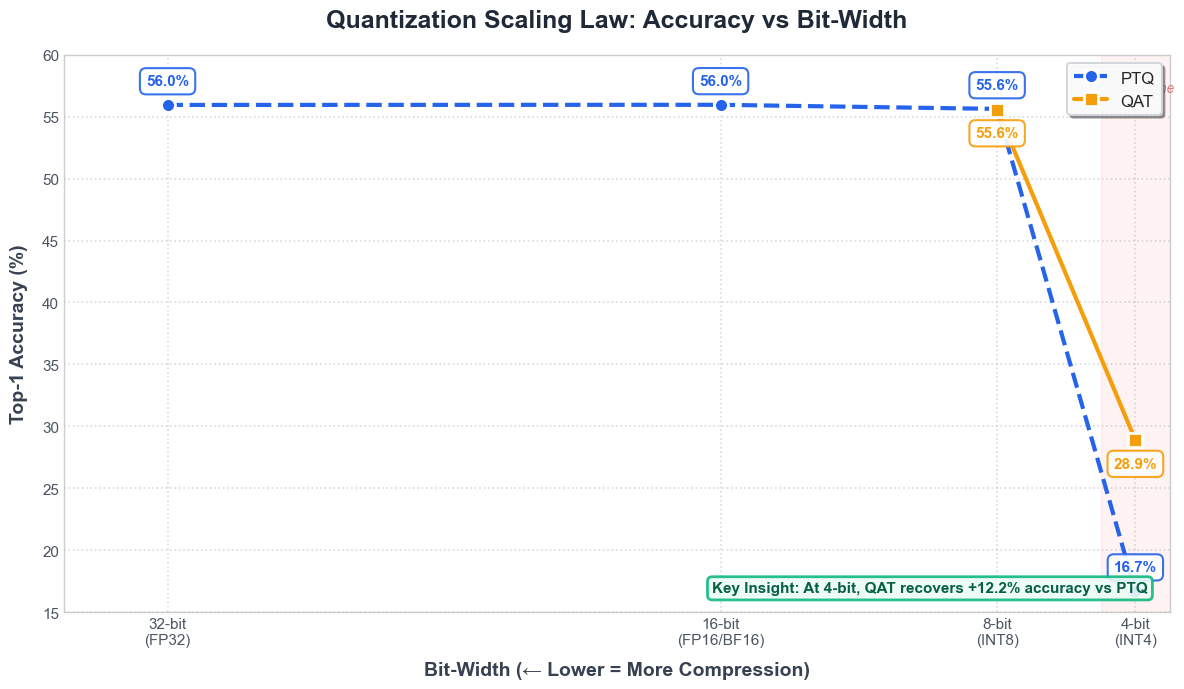


Plot saved as 'quantization_scaling_law.png'

Summary Statistics:
  • PTQ @ 4-bit: 16.7%
  • QAT @ 4-bit: 28.9%
  • Improvement: +12.2%


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- PTQ Results ----
results_data_ptq = [
    ['PTQ', 'fp32', 32, 55.95],
    ['PTQ', 'fp16', 16, 55.91],
    ['PTQ', 'bf16', 16, 56.01],
    ['PTQ', 'int8_symm', 8, 55.63],
    ['PTQ', 'int4_symm', 4, 14.70],
    ['PTQ', 'int4_asymm', 4, 18.69],
]
df_ptq = pd.DataFrame(results_data_ptq, columns=['Method', 'Precision', 'Bits', 'Accuracy'])

# ---- QAT Results ----
results_data_qat = [
    ['QAT', 'int8_symm', 8, 55.57],
    ['QAT', 'int4_symm', 4, 27.13],
    ['QAT', 'int4_asymm', 4, 30.63],
]
df_qat = pd.DataFrame(results_data_qat, columns=['Method', 'Precision', 'Bits', 'Accuracy'])

# Aggregate data by bit-width (average if multiple entries)
df_ptq_agg = df_ptq.groupby('Bits')['Accuracy'].mean().reset_index()
df_qat_agg = df_qat.groupby('Bits')['Accuracy'].mean().reset_index()

# ---- Create Beautiful Plot ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors
ptq_color = '#2563eb'  # Blue
qat_color = '#f59e0b'  # Orange

# Sort by bits descending
df_ptq_agg = df_ptq_agg.sort_values('Bits', ascending=False)
df_qat_agg = df_qat_agg.sort_values('Bits', ascending=False)

# Plot PTQ (dashed line)
ax.plot(df_ptq_agg['Bits'], df_ptq_agg['Accuracy'], 
        marker='o', markersize=10, linewidth=3, color=ptq_color,
        linestyle='--', label='PTQ', 
        markeredgewidth=2, markeredgecolor='white', zorder=3)

# Plot QAT (solid line)
ax.plot(df_qat_agg['Bits'], df_qat_agg['Accuracy'], 
        marker='s', markersize=10, linewidth=3, color=qat_color,
        linestyle='-', label='QAT',
        markeredgewidth=2, markeredgecolor='white', zorder=3)

# Annotate PTQ points (ABOVE the line)
for _, row in df_ptq_agg.iterrows():
    ax.annotate(f"{row['Accuracy']:.1f}%", 
                xy=(row['Bits'], row['Accuracy']),
                xytext=(0, 12),  # Offset upward
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=ptq_color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor=ptq_color, alpha=0.9, linewidth=1.5))

# Annotate QAT points (BELOW the line)
for _, row in df_qat_agg.iterrows():
    ax.annotate(f"{row['Accuracy']:.1f}%", 
                xy=(row['Bits'], row['Accuracy']),
                xytext=(0, -12),  # Offset downward
                textcoords='offset points',
                ha='center', va='top',
                fontsize=11, fontweight='bold', color=qat_color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor=qat_color, alpha=0.9, linewidth=1.5))

# Titles & labels
ax.set_title('Quantization Scaling Law: Accuracy vs Bit-Width', 
             fontsize=18, weight='bold', pad=20, color='#1f2937')
ax.set_xlabel('Bit-Width (← Lower = More Compression)', 
              fontsize=14, labelpad=10, weight='semibold', color='#374151')
ax.set_ylabel('Top-1 Accuracy (%)', 
              fontsize=14, labelpad=10, weight='semibold', color='#374151')

# Axes settings
ax.set_xticks([32, 16, 8, 4])
ax.set_xticklabels(['32-bit\n(FP32)', '16-bit\n(FP16/BF16)', '8-bit\n(INT8)', '4-bit\n(INT4)'])
ax.invert_xaxis()
ax.set_xlim(35, 3)
ax.set_ylim(15, 60)
ax.tick_params(axis='both', labelsize=11, colors='#4b5563')

# Enhanced grid
ax.grid(True, linestyle=':', linewidth=1.2, alpha=0.4, color='#9ca3af')
ax.set_axisbelow(True)

# Legend with better styling
legend = ax.legend(loc='upper right', frameon=True, fontsize=12, 
                   shadow=True, fancybox=True, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#d1d5db')
legend.get_frame().set_linewidth(1.5)

# Add background shading for dramatic effect at 4-bit
ax.axvspan(3, 5, alpha=0.05, color='red', zorder=0)
ax.text(4, 57, 'Critical Zone', fontsize=10, ha='center', 
        style='italic', color='#dc2626', alpha=0.6)

# Add insight box
textstr = 'Key Insight: At 4-bit, QAT recovers +12.2% accuracy vs PTQ'
props = dict(boxstyle='round', facecolor='#ecfdf5', edgecolor='#10b981', 
             alpha=0.9, linewidth=2)
ax.text(0.98, 0.03, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=props, weight='semibold', color='#065f46')

# Tight layout
plt.tight_layout()
plt.savefig('quantization_scaling_law.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\nPlot saved as 'quantization_scaling_law.png'")
print("\nSummary Statistics:")
print(f"  • PTQ @ 4-bit: {df_ptq_agg[df_ptq_agg['Bits']==4]['Accuracy'].values[0]:.1f}%")
print(f"  • QAT @ 4-bit: {df_qat_agg[df_qat_agg['Bits']==4]['Accuracy'].values[0]:.1f}%")
print(f"  • Improvement: +{df_qat_agg[df_qat_agg['Bits']==4]['Accuracy'].values[0] - df_ptq_agg[df_ptq_agg['Bits']==4]['Accuracy'].values[0]:.1f}%")

### Mixed Precisions

### Baselin (Uniform)

In [26]:
print("\n--- Task 3: Mixed-Precision Quantization Analysis ---")

mixed_precision_results = []
dummy_input = torch.randn(1, 3, 32, 32, device=DEVICE)
model_to_quantize = deepcopy(vgg11_fp32)
low_bitwidth = 4

uniform_model = ptq_pipeline(model_to_quantize, calib_loader, DEVICE, bitwidth=low_bitwidth)
uniform_latency = measure_latency(uniform_model, DEVICE, dummy_input)
uniform_acc = evaluate(uniform_model, test_loader, DEVICE)    
uniform_size = get_model_size(uniform_model, bitwidth=low_bitwidth)                       
mixed_precision_results.append({
    'Config': f'Uniform INT{low_bitwidth}',
    'Accuracy': uniform_acc,
    'Size (MB)': uniform_size,
    'Latency (ms)': uniform_latency
})

print(f"Uniform INT{low_bitwidth} | "
      f"Accuracy: {uniform_acc:.2f}%, Size: {uniform_size:.2f} MB, "
      f"Latency: {uniform_latency:.3f} ms")


--- Task 3: Mixed-Precision Quantization Analysis ---
Calibrating model...
Applying quantization...
PTQ completed!
Uniform INT4 | Accuracy: 14.32%, Size: 61.63 MB, Latency: 7.371 ms


### Simple Mixed Precision

In [27]:
# --- (ii) Simple Mixed-Precision (First and Last Layers in FP32) ---
print("\n--- Running Simple Mixed-Precision (First/Last Layer in FP32) ---")
model_simple_mixed = deepcopy(vgg11_fp32)
# For VGG-11: 'features.0' is the first conv, 'classifier.6' is the last linear layer
high_precision_layers = ['features.0', 'classifier.6']
simple_policy = {name: 32 if name in high_precision_layers else low_bitwidth for name, mod in model_simple_mixed.named_modules() if isinstance(mod, (nn.Conv2d, nn.Linear))}

model_simple_mixed = bnfold_vgg(model_simple_mixed, DEVICE)
observers = calibrate_model(model_simple_mixed, calib_loader, DEVICE, bitwidth=low_bitwidth)
model_simple_mixed = apply_mixed_precision_ptq(model_simple_mixed, observers, simple_policy, low_bitwidth=low_bitwidth)
model_simple_mixed = convert_to_mixed_precision_model(model_simple_mixed, simple_policy, low_bitwidth=low_bitwidth)

simple_mixed_acc = evaluate(model_simple_mixed, test_loader, DEVICE)
simple_mixed_size = get_model_size(model_simple_mixed, bitwidth=low_bitwidth) # Use get_model_size as it has FP32 parts
simple_mixed_latency = measure_latency(model_simple_mixed, DEVICE, dummy_input)
mixed_precision_results.append({'Config': 'Simple Mixed', 'Accuracy': simple_mixed_acc, 'Size (MB)': simple_mixed_size, 'Latency (ms)': simple_mixed_latency})
print(f"Simple Mixed | Accuracy: {simple_mixed_acc:.2f}%, Size: {simple_mixed_size:.2f} MB, Latency: {simple_mixed_latency:.3f} ms")


--- Running Simple Mixed-Precision (First/Last Layer in FP32) ---
Quantizing layer 'features.3' to 4-bit.
Quantizing layer 'features.6' to 4-bit.
Quantizing layer 'features.8' to 4-bit.
Quantizing layer 'features.11' to 4-bit.
Quantizing layer 'features.13' to 4-bit.
Quantizing layer 'features.16' to 4-bit.
Quantizing layer 'features.18' to 4-bit.
Quantizing layer 'classifier.0' to 4-bit.
Quantizing layer 'classifier.3' to 4-bit.
Simple Mixed | Accuracy: 30.20%, Size: 63.01 MB, Latency: 6.534 ms


### Adaptive Mixed Precision

In [31]:
# --- (iii) Adaptive Mixed-Precision (Variance-Based) ---
print("\n--- Running Adaptive Mixed-Precision (Variance-Based) ---")
model_adaptive_mixed = deepcopy(vgg11_fp32)

# <<< FIX: Fold the Batch Norm layers FIRST, before any analysis >>>
print("Folding Batch Normalization layers...")
model_adaptive_mixed = bnfold_vgg(model_adaptive_mixed, DEVICE)

# Now, perform all analysis on the SAME, consistent, folded model
manager = MixedPrecisionManager(model_adaptive_mixed, calib_loader)
print("Profiling the FOLDED model for activation variance...")
variances = manager.profile_activation_variance(device=DEVICE)

# Keep top 20% most sensitive layers in FP32
adaptive_policy = manager.get_quantization_policy(variances, sensitivity_percentile=0.5, high_precision_bits=32, low_precision_bits=low_bitwidth)

# Calibrate the FOLDED model
print("Calibrating the FOLDED model...")
observers = calibrate_model(model_adaptive_mixed, calib_loader, DEVICE, bitwidth=low_bitwidth)

# Apply quantization and convert
model_adaptive_mixed = apply_mixed_precision_ptq(model_adaptive_mixed, observers, adaptive_policy, low_bitwidth=low_bitwidth)
model_adaptive_mixed = convert_to_mixed_precision_model(model_adaptive_mixed, adaptive_policy, low_bitwidth=low_bitwidth)

adaptive_mixed_acc = evaluate(model_adaptive_mixed, test_loader, DEVICE)
adaptive_mixed_size = get_model_size(model_adaptive_mixed, bitwidth=low_bitwidth)
adaptive_mixed_latency = measure_latency(model_adaptive_mixed, DEVICE, dummy_input)
mixed_precision_results.append({'Config': 'Adaptive Mixed', 'Accuracy': adaptive_mixed_acc, 'Size (MB)': adaptive_mixed_size, 'Latency (ms)': adaptive_mixed_latency})
print(f"Adaptive Mixed | Accuracy: {adaptive_mixed_acc:.2f}%, Size: {adaptive_mixed_size:.2f} MB, Latency: {adaptive_mixed_latency:.3f} ms")


--- Running Adaptive Mixed-Precision (Variance-Based) ---
Folding Batch Normalization layers...
Profiling the FOLDED model for activation variance...
Layer 'features.0' is sensitive (variance 0.6767 >= threshold 0.6736). Assigning 32-bit.
Layer 'features.6' is sensitive (variance 0.6746 >= threshold 0.6736). Assigning 32-bit.
Layer 'features.8' is sensitive (variance 0.6736 >= threshold 0.6736). Assigning 32-bit.
Layer 'features.11' is sensitive (variance 0.6746 >= threshold 0.6736). Assigning 32-bit.
Layer 'classifier.0' is sensitive (variance 3.5229 >= threshold 0.6736). Assigning 32-bit.
Layer 'classifier.6' is sensitive (variance 10.3645 >= threshold 0.6736). Assigning 32-bit.
Calibrating the FOLDED model...
Quantizing layer 'features.3' to 4-bit.
Quantizing layer 'features.13' to 4-bit.
Quantizing layer 'features.16' to 4-bit.
Quantizing layer 'features.18' to 4-bit.
Quantizing layer 'classifier.3' to 4-bit.
Adaptive Mixed | Accuracy: 38.80%, Size: 412.90 MB, Latency: 2.519 ms


### Plotting

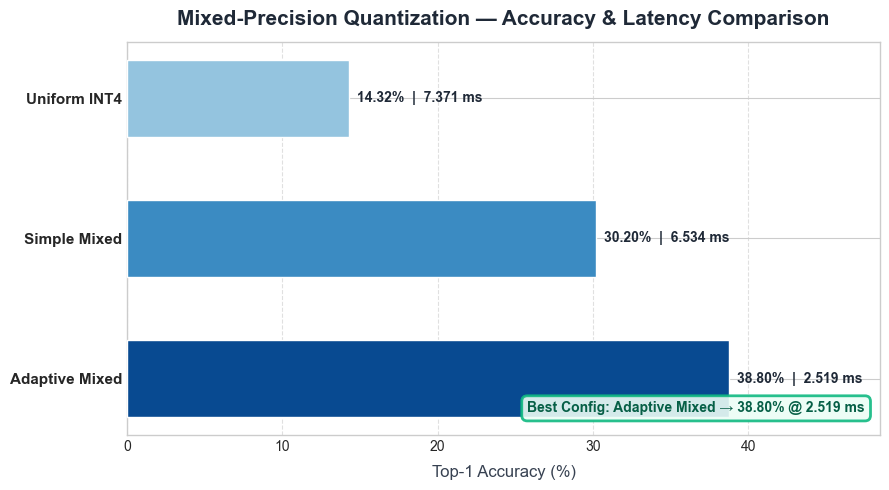


--- Mixed Precision Quantization Summary ---
  • Uniform INT4: Accuracy = 14.32%, Latency = 7.371 ms
  • Simple Mixed: Accuracy = 30.20%, Latency = 6.534 ms
  • Adaptive Mixed: Accuracy = 38.80%, Latency = 2.519 ms

Best Config: Adaptive Mixed (38.80% @ 2.519 ms)


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Data ---
data = [
    ['Uniform INT4', 14.32, 7.371],
    ['Simple Mixed', 30.20, 6.534],
    ['Adaptive Mixed', 38.80, 2.519],
]

df_plot = pd.DataFrame(data, columns=['Config', 'Accuracy', 'Latency'])

# --- Sort by Accuracy (descending for visualization) ---
df_plot = df_plot.sort_values('Accuracy', ascending=True)
configs = df_plot['Config'].tolist()
accuracies = df_plot['Accuracy'].values
latencies = df_plot['Latency'].values
y = np.arange(len(df_plot))

# --- Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = plt.get_cmap('Blues')(np.linspace(0.4, 0.9, len(df_plot)))
bars = ax.barh(y, accuracies, color=bar_colors, edgecolor='white', height=0.55, zorder=3)

# --- Annotate accuracy & latency ---
for bar, acc, lat in zip(bars, accuracies, latencies):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{acc:.2f}%  |  {lat:.3f} ms",
            va='center', fontsize=10, weight='semibold', color='#1f2937')

# --- Styling ---
ax.set_yticks(y)
ax.set_yticklabels(configs, fontsize=11, weight='semibold')
ax.set_xlabel('Top-1 Accuracy (%)', fontsize=12, labelpad=8, color='#374151')
ax.set_title('Mixed-Precision Quantization — Accuracy & Latency Comparison',
             fontsize=15, weight='bold', pad=12, color='#1f2937')

ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(0, max(accuracies) * 1.25)
ax.invert_yaxis()

# --- Insight box (optional) ---
best_cfg = df_plot.iloc[-1]
textstr = f"Best Config: {best_cfg['Config']} → {best_cfg['Accuracy']:.2f}% @ {best_cfg['Latency']:.3f} ms"
props = dict(boxstyle='round,pad=0.4', facecolor='#ecfdf5', edgecolor='#10b981', alpha=0.9, linewidth=2)
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=props, color='#065f46', weight='semibold')

plt.tight_layout()
plt.savefig('mixed_precision_accuracy_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- Report summary ---
print("\n--- Mixed Precision Quantization Summary ---")
for _, row in df_plot.iterrows():
    print(f"  • {row['Config']}: Accuracy = {row['Accuracy']:.2f}%, Latency = {row['Latency']:.3f} ms")

best = df_plot.iloc[-1]
print(f"\nBest Config: {best['Config']} ({best['Accuracy']:.2f}% @ {best['Latency']:.3f} ms)")


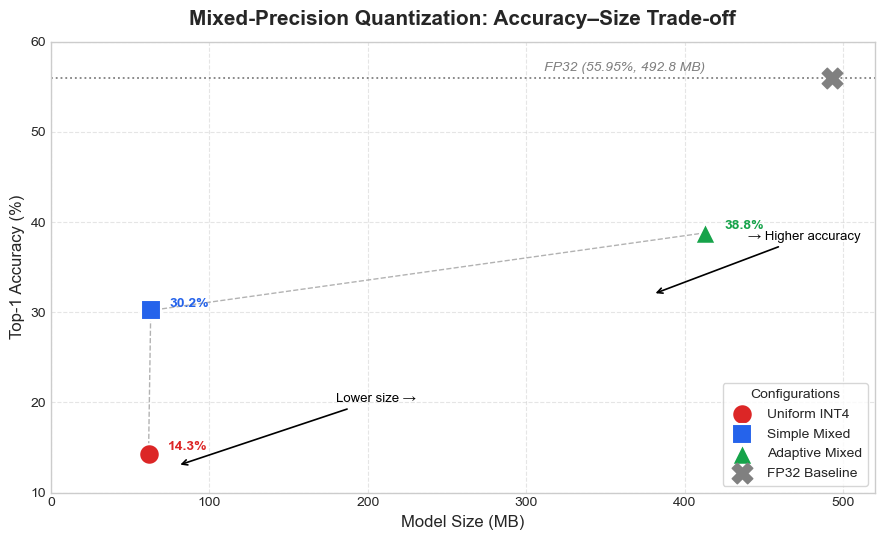

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data ---
data = [
    ['Uniform INT4', 14.32, 61.63],
    ['Simple Mixed', 30.20, 63.01],
    ['Adaptive Mixed', 38.80, 412.90],
]
df = pd.DataFrame(data, columns=['Config', 'Accuracy', 'Size (MB)'])

# --- Baseline ---
baseline_size, baseline_acc = 492.81, 55.95

# --- Sort for line plotting (Pareto frontier style) ---
df = df.sort_values('Size (MB)')

# --- Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ['#dc2626', '#2563eb', '#16a34a']
markers = ['o', 's', '^']

# Plot connecting line (Pareto-like)
ax.plot(df['Size (MB)'], df['Accuracy'], color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1)

# Plot each configuration
for i, row in df.iterrows():
    ax.scatter(row['Size (MB)'], row['Accuracy'],
               s=220, color=colors[i], marker=markers[i], edgecolor='white', linewidth=1.5,
               label=row['Config'], zorder=3)
    ax.text(row['Size (MB)'] + 12, row['Accuracy'] + 0.4, 
            f"{row['Accuracy']:.1f}%", fontsize=10, weight='semibold', color=colors[i])

# --- FP32 Baseline ---
ax.axhline(y=baseline_acc, color='grey', linestyle=':', linewidth=1.3)
ax.scatter(baseline_size, baseline_acc, c='grey', marker='X', s=220, label='FP32 Baseline', zorder=3)
ax.text(baseline_size - 80, baseline_acc + 0.8, "FP32 (55.95%, 492.8 MB)",
        fontsize=10, color='gray', ha='right', style='italic')

# --- Annotations for trade-off insight ---
ax.annotate('Lower size →', xy=(80, 13), xytext=(180, 20),
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
            fontsize=9.5, color='black')

ax.annotate('→ Higher accuracy', xy=(380, 32), xytext=(440, 38),
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
            fontsize=9.5, color='black')

# --- Titles & Labels ---
ax.set_title('Mixed-Precision Quantization: Accuracy–Size Trade-off', fontsize=15, weight='bold', pad=12)
ax.set_xlabel('Model Size (MB)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)

# --- Limits & Grid ---
ax.set_xlim(0, 520)
ax.set_ylim(10, 60)
ax.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
ax.legend(title='Configurations', fontsize=10, loc='lower right', frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig('mixed_precision_tradeoff_curve.png', dpi=300, bbox_inches='tight')
plt.show()


### Visualizing Activation Outliers


--- Task 4: Effect of Outliers on Quantization ---
Capturing activations for layers: ['features.0', 'features.3', 'features.8', 'features.13', 'features.20', 'classifier.0', 'classifier.3', 'classifier.6']


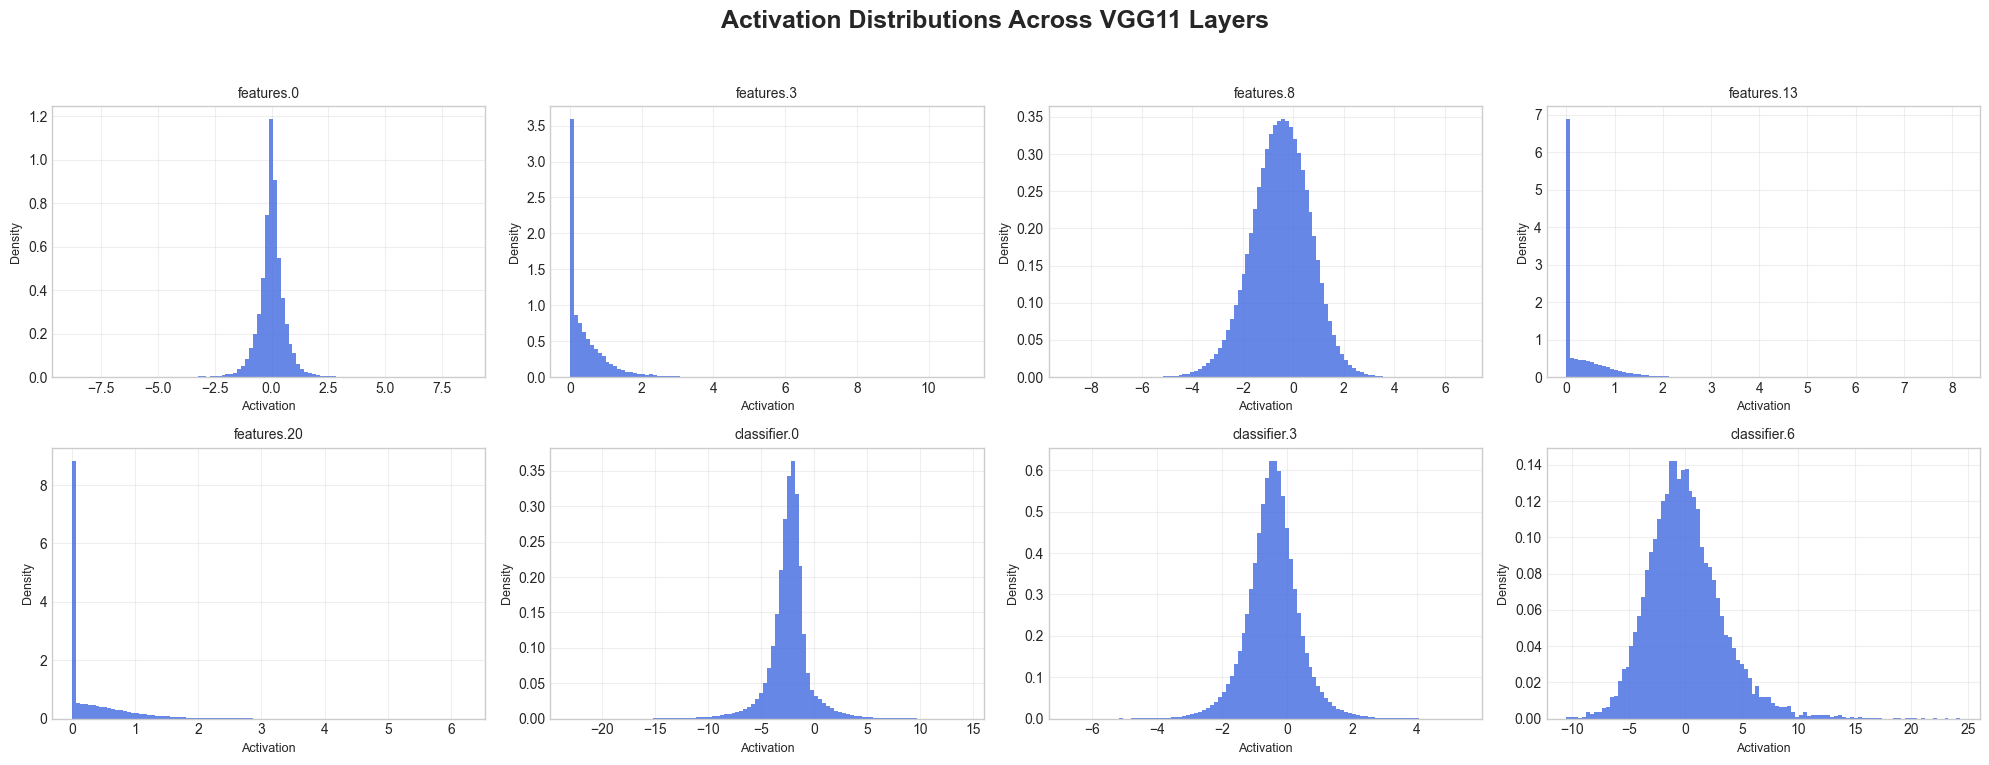

In [ ]:
print("\n--- Task 4: Effect of Outliers on Quantization ---")

# --- Layers to Inspect ---
layers_to_inspect = [
    'features.0', 'features.3', 'features.8', 'features.13', 'features.20',
    'classifier.0', 'classifier.3', 'classifier.6'
]

visualizer = ActivationVisualizer(vgg11_fp32, layers_to_inspect)
print(f"Capturing activations for layers: {layers_to_inspect}")
visualizer.capture_activations(calib_loader, DEVICE)
visualizer.plot_histograms()
visualizer.remove_hooks()


### Clipped Quantization


=== Comparing Standard vs. Clipped PTQ ===

--- 4-bit Quantization ---
Running Standard PTQ (4-bit)...
Calibrating model...
Applying quantization...
PTQ completed!
Standard PTQ (4-bit) Accuracy: 15.11%
Running Clipped PTQ (4-bit, 99.9th percentile)...
Starting CLIPPED PTQ with bitwidth=4, percentile=99.9
Calibrating model with percentile clipping...
Calculating clipped params for layer 'features.0':
  Input stats:
  - (Sampled) Original min/max: -1.897/2.025. Clipped min/max: -1.897/2.025
  Output stats:
  - (Sampled) Original min/max: -8.076/8.373. Clipped min/max: -4.430/4.667
Calculating clipped params for layer 'features.3':
  Input stats:
  - (Sampled) Original min/max: 0.000/10.509. Clipped min/max: 0.000/5.468
  Output stats:
  - (Sampled) Original min/max: -5.823/5.045. Clipped min/max: -3.939/3.330
Calculating clipped params for layer 'features.6':
  Input stats:
  - (Sampled) Original min/max: 0.000/11.140. Clipped min/max: 0.000/3.889
  Output stats:
  - (Sampled) Original 

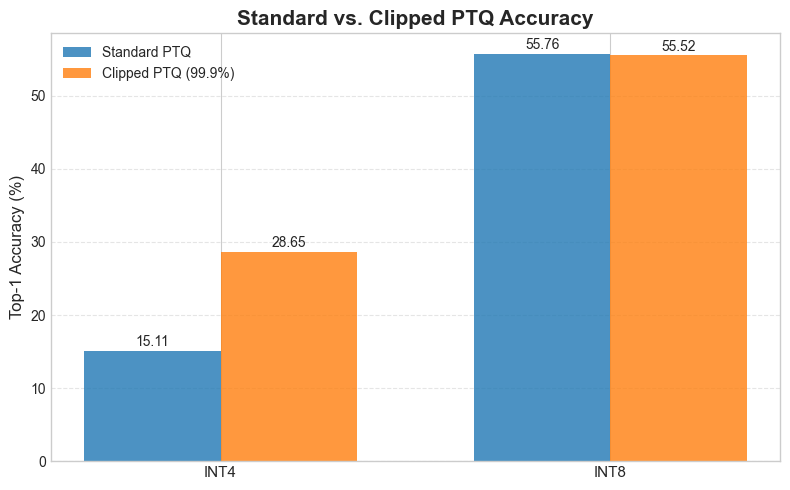

In [ ]:
from copy import deepcopy

print("\n=== Comparing Standard vs. Clipped PTQ ===")

comparison_results = []

for bitwidth in [4, 8]:
    print(f"\n--- {bitwidth}-bit Quantization ---")

    # --- Standard PTQ ---
    print(f"Running Standard PTQ ({bitwidth}-bit)...")
    model_std = ptq_pipeline(deepcopy(vgg11_fp32), calib_loader, DEVICE, bitwidth=bitwidth)
    acc_std = evaluate(model_std, test_loader, DEVICE)
    print(f"Standard PTQ ({bitwidth}-bit) Accuracy: {acc_std:.2f}%")

    # --- Clipped PTQ ---
    print(f"Running Clipped PTQ ({bitwidth}-bit, 99.9th percentile)...")
    model_clip = ptq_pipeline_clipped(deepcopy(vgg11_fp32), calib_loader, DEVICE, bitwidth=bitwidth, percentile=99.9)
    acc_clip = evaluate(model_clip, test_loader, DEVICE)
    print(f"Clipped PTQ ({bitwidth}-bit) Accuracy: {acc_clip:.2f}%")

    # --- Record Results ---
    comparison_results.append({
        "Precision": f"INT{bitwidth}",
        "Standard Accuracy": acc_std,
        "Clipped Accuracy": acc_clip,
        "Diff": acc_clip - acc_std
    })

# --- Convert to DataFrame for Easy Viewing ---
df_comparison = pd.DataFrame(comparison_results)
print("\n=== PTQ Comparison Results ===")
print(df_comparison.to_string(index=False))

# --- Beautiful Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, df_comparison["Standard Accuracy"], width, label='Standard PTQ', alpha=0.8)
bars2 = ax.bar(x + width/2, df_comparison["Clipped Accuracy"], width, label='Clipped PTQ (99.9%)', alpha=0.8)

# Annotate values on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.2, f"{height:.2f}", ha='center', va='bottom', fontsize=10)

ax.set_title("Standard vs. Clipped PTQ Accuracy", fontsize=15, weight='bold')
ax.set_ylabel("Top-1 Accuracy (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_comparison["Precision"], fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



--- Visualizing the Effect of Clipping on Activation Distributions ---


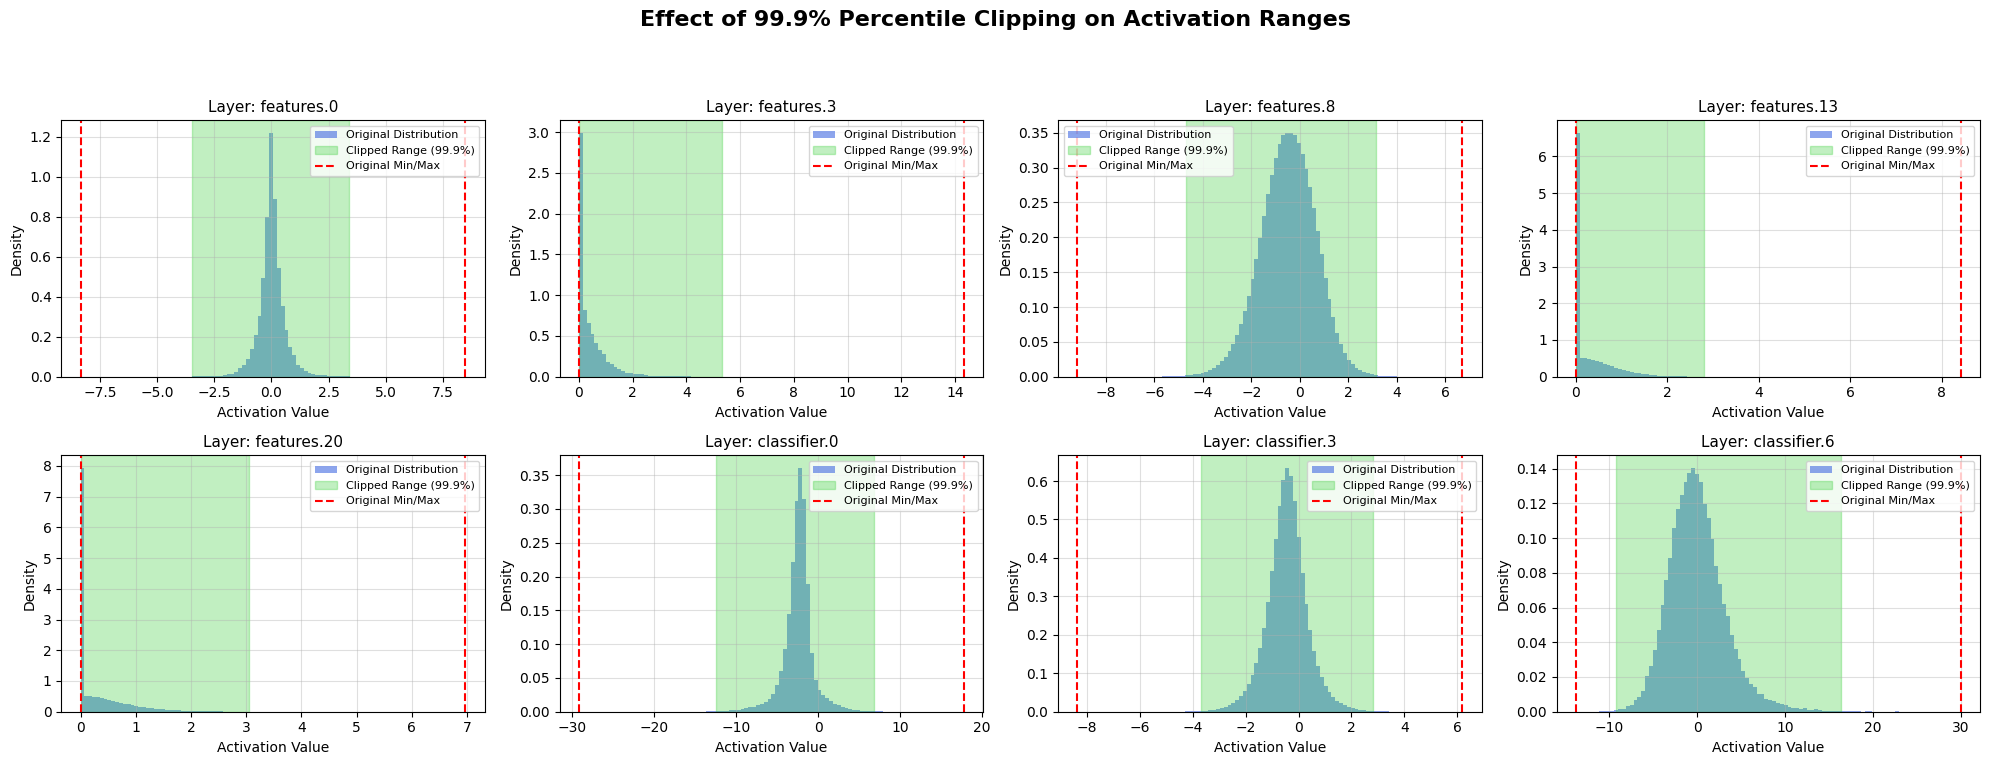


Plot saved as 'clipped_distributions_visualization.png'


In [5]:
layers_to_inspect = [
    'features.0', 'features.3', 'features.8', 'features.13', 'features.20',
    'classifier.0', 'classifier.3', 'classifier.6'
]
clip_visualizer = ClippedActivationVisualizer(vgg11_fp32, layers_to_inspect)
print("\n--- Visualizing the Effect of Clipping on Activation Distributions ---")
clip_visualizer.capture_activations(calib_loader, DEVICE)
clip_visualizer.plot_clipped_distributions(percentile=99.9)
clip_visualizer.remove_hooks()
print("\nPlot saved as 'clipped_distributions_visualization.png'")